# Ford GoBike System Data — Explanatory Analysis
## February 2019

---

## Investigation Overview

**Central Question:** *How do different types of Ford GoBike users in the San Francisco Bay Area use the system, and what patterns emerge from their trip behavior?*

Through exploratory analysis I found that the most important dimension separating user behavior is **user type** (Subscriber vs. Customer). This explanatory analysis communicates the three most compelling findings:

1. **Subscribers and Customers have fundamentally different trip durations.**
2. **Commuter patterns dominate on weekdays; subscribers behave like tourists on weekends.**
3. **Gender affects trip duration, but user type is the stronger predictor.**

---

## Dataset Overview

The Ford GoBike dataset covers all individual bike-share trips in the greater San Francisco Bay Area during **February 2019**. The original dataset contained 183,412 trips and 16 features including trip duration, start/end timestamps, station locations, bike IDs, user type, member birth year, and member gender. After removing extreme outliers (trips > 3 hours, riders with implausible ages), **~181,000 trips** were retained for analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12


def resolve_repo_paths():
    """Resolve data and figures paths whether the notebook is run from the repo root or notebooks/ folder."""
    base_candidates = [Path.cwd(), Path.cwd().parent]
    for base in base_candidates:
        data_file = base / 'data' / 'fordgobike_2019_02.csv'
        if data_file.exists():
            figures_dir = base / 'figures'
            figures_dir.mkdir(parents=True, exist_ok=True)
            return data_file, figures_dir
    raise FileNotFoundError('Could not find data/fordgobike_2019_02.csv from the current working directory.')


DATA_FILE, FIGURES_DIR = resolve_repo_paths()

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_FILE, on_bad_lines='skip')
df['start_time']   = pd.to_datetime(df['start_time'])
df['end_time']     = pd.to_datetime(df['end_time'])
df['duration_min'] = df['duration_sec'] / 60
df['age']          = 2019 - df['member_birth_year']
df['hour_of_day']  = df['start_time'].dt.hour
df['day_of_week']  = df['start_time'].dt.day_name()
df['date']         = df['start_time'].dt.date
df['weekend']      = df['day_of_week'].isin(['Saturday', 'Sunday']).map({True: 'Weekend', False: 'Weekday'})

# Clean
df = df[df['age'].between(18, 80) | df['age'].isna()]
df = df[df['duration_min'] <= 180]

print(f'Trips loaded: {len(df):,}')

Trips loaded: 182,803


---
## Finding 1: Subscribers Take Short, Efficient Trips — Customers Take Leisurely Ones

The most important difference between user types is trip duration. The chart below shows the full distributions side-by-side on a log scale.

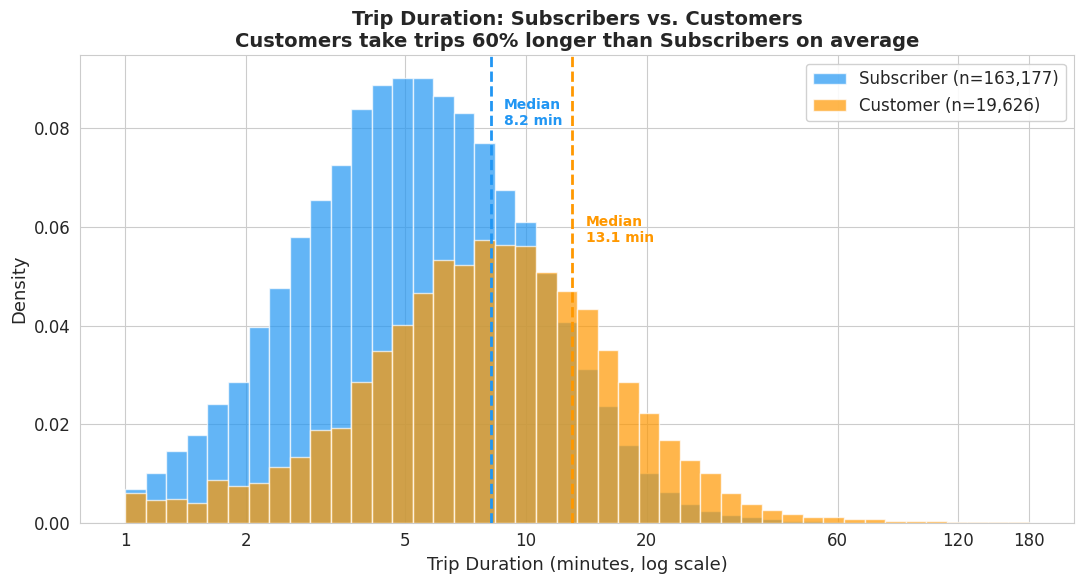

Subscriber: median=8.2 min, mean=10.1 min, n=163,177
Customer: median=13.1 min, mean=18.5 min, n=19,626


In [2]:
def plot_finding1(df):
    """
    Polished histogram comparing trip duration distributions for
    Subscribers vs Customers on a log scale.
    """
    fig, ax = plt.subplots(figsize=(11, 6))
    
    bins = np.logspace(np.log10(1), np.log10(180), 45)
    
    for utype, color, alpha in [('Subscriber', '#2196F3', 0.7), ('Customer', '#FF9800', 0.7)]:
        data = df[df['user_type'] == utype]['duration_min']
        med  = data.median()
        ax.hist(data, bins=bins, color=color, alpha=alpha, label=f'{utype} (n={len(data):,})', density=True)
        ax.axvline(med, color=color, linestyle='--', linewidth=2)
        ax.text(med * 1.08, ax.get_ylim()[1] * 0.85 if utype == 'Subscriber' else ax.get_ylim()[1] * 0.6,
                f'Median\n{med:.1f} min', color=color, fontsize=10, fontweight='bold')
    
    ax.set_xscale('log')
    tick_vals = [1, 2, 5, 10, 20, 60, 120, 180]
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([str(v) for v in tick_vals])
    ax.set_xlabel('Trip Duration (minutes, log scale)', fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.set_title('Trip Duration: Subscribers vs. Customers\n'
                 'Customers take trips 60% longer than Subscribers on average',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=12, framealpha=0.9)
    
    ax.annotate('Subscriber peak:\n~8 min commutes',
                xy=(8, 0.55), xytext=(3.5, 0.65),
                arrowprops=dict(arrowstyle='->', color='#2196F3'),
                color='#2196F3', fontsize=10)
    ax.annotate('Customer peak:\n~13 min leisure rides',
                xy=(13, 0.28), xytext=(25, 0.45),
                arrowprops=dict(arrowstyle='->', color='#FF9800'),
                color='#FF9800', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'explanatory_1_duration_usertype.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print key stats
    for utype in ['Subscriber', 'Customer']:
        d = df[df['user_type'] == utype]['duration_min']
        print(f"{utype}: median={d.median():.1f} min, mean={d.mean():.1f} min, n={len(d):,}")


plot_finding1(df)

**Key Insight:** Subscribers have a sharp, tall peak centered around **8 minutes** — consistent with short point-to-point commute trips. Customers have a flatter, wider distribution peaking around **13 minutes**, consistent with exploring the city or riding for pleasure. The dashed median lines make the separation unmistakable.

---
## Finding 2: Subscribers Are Commuters — Customers Are Explorers

The hourly usage pattern tells the full story of *when* each user type rides. The facet chart below shows average trips per hour, split by user type and by weekday vs. weekend.

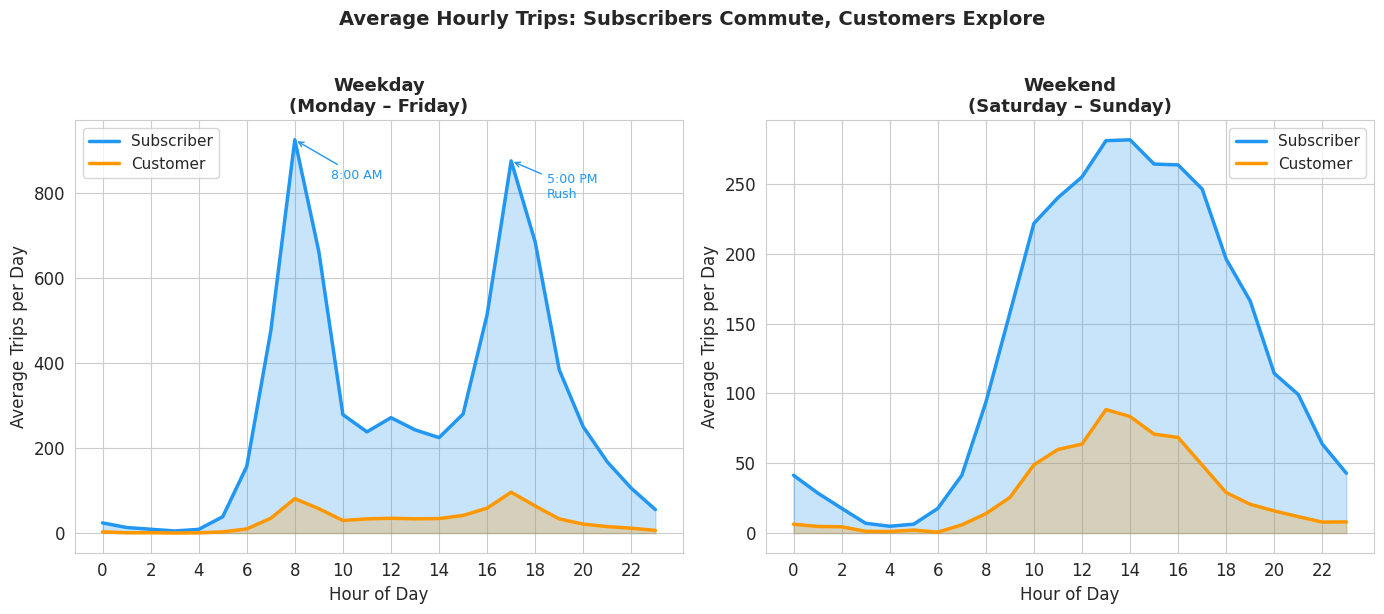

In [3]:
def plot_finding2(df):
    """
    Polished facet line chart of average hourly trips by user type
    and day type (Weekday vs Weekend).
    """
    # Aggregate
    hourly = df.groupby(['user_type', 'weekend', 'hour_of_day']).size().reset_index(name='trips')
    day_counts = df.groupby(['user_type', 'weekend'])['date'].nunique().reset_index(name='n_days')
    hourly = hourly.merge(day_counts, on=['user_type', 'weekend'])
    hourly['avg_trips'] = hourly['trips'] / hourly['n_days']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
    colors = {'Subscriber': '#2196F3', 'Customer': '#FF9800'}
    
    for ax, day_type, title_sfx in zip(axes, ['Weekday', 'Weekend'], ['Monday – Friday', 'Saturday – Sunday']):
        sub = hourly[hourly['weekend'] == day_type]
        for utype in ['Subscriber', 'Customer']:
            d = sub[sub['user_type'] == utype].sort_values('hour_of_day')
            ax.fill_between(d['hour_of_day'], d['avg_trips'], alpha=0.25, color=colors[utype])
            ax.plot(d['hour_of_day'], d['avg_trips'], color=colors[utype], linewidth=2.5, label=utype)
        
        ax.set_xticks(range(0, 24, 2))
        ax.set_xlabel('Hour of Day', fontsize=12)
        ax.set_ylabel('Average Trips per Day', fontsize=12)
        ax.set_title(f'{day_type}\n({title_sfx})', fontsize=13, fontweight='bold')
        ax.legend(fontsize=11)
        
        # Annotate subscriber peaks on weekday
        if day_type == 'Weekday':
            sub_data = sub[sub['user_type'] == 'Subscriber'].sort_values('hour_of_day')
            for peak_h in [8, 17]:
                peak_v = sub_data[sub_data['hour_of_day'] == peak_h]['avg_trips'].values[0]
                ax.annotate(f'{peak_h}:00 AM' if peak_h < 12 else f'{peak_h-12}:00 PM\nRush',
                            xy=(peak_h, peak_v),
                            xytext=(peak_h + 1.5, peak_v * 0.9),
                            arrowprops=dict(arrowstyle='->', color='#2196F3'),
                            color='#2196F3', fontsize=9)
    
    fig.suptitle('Average Hourly Trips: Subscribers Commute, Customers Explore',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'explanatory_2_hourly_patterns.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_finding2(df)

**Key Insight:**  
- On **weekdays**, Subscribers show twin rush-hour spikes at 8 AM and 5 PM — a textbook commuter signature. Customers show a gentle midday rise.
- On **weekends**, Subscriber behavior shifts dramatically to a single midday peak, resembling the Customer pattern. Customers maintain their midday pattern.
- This confirms that the bike-share system serves two distinct roles: **daily transit infrastructure** for subscribers and **recreational/tourist exploration** for customers.

---
## Finding 3: User Type Dominates Gender in Predicting Trip Duration

While gender alone shows some differences in trip duration, the dominant factor is always user type. This clustered bar chart controls for both simultaneously.

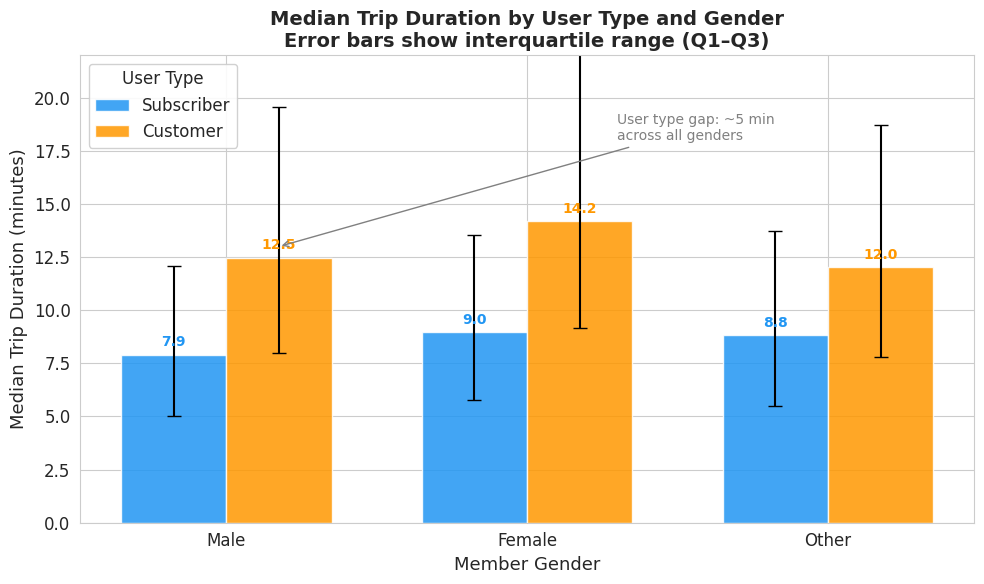

In [4]:
def plot_finding3(df):
    """
    Polished clustered bar chart showing median trip duration
    by user type and gender, with error bars (IQR).
    """
    clean = df.dropna(subset=['member_gender'])
    genders = ['Male', 'Female', 'Other']
    user_types = ['Subscriber', 'Customer']
    
    # Compute medians and IQR
    stats = clean.groupby(['user_type', 'member_gender'])['duration_min'].describe()
    medians = clean.groupby(['user_type', 'member_gender'])['duration_min'].median().unstack()
    q1 = clean.groupby(['user_type', 'member_gender'])['duration_min'].quantile(0.25).unstack()
    q3 = clean.groupby(['user_type', 'member_gender'])['duration_min'].quantile(0.75).unstack()
    
    x = np.arange(len(genders))
    width = 0.35
    colors = {'Subscriber': '#2196F3', 'Customer': '#FF9800'}
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, (utype, offset) in enumerate(zip(user_types, [-width/2, width/2])):
        med_vals = [medians.loc[utype, g] for g in genders]
        q1_vals  = [q1.loc[utype, g] for g in genders]
        q3_vals  = [q3.loc[utype, g] for g in genders]
        err_lo   = np.array(med_vals) - np.array(q1_vals)
        err_hi   = np.array(q3_vals)  - np.array(med_vals)
        
        bars = ax.bar(x + offset, med_vals, width, label=utype,
                      color=colors[utype], alpha=0.85, edgecolor='white')
        ax.errorbar(x + offset, med_vals,
                    yerr=[err_lo, err_hi],
                    fmt='none', color='black', capsize=5, linewidth=1.5)
        
        for bar, val in zip(bars, med_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                    f'{val:.1f}', ha='center', fontsize=10, fontweight='bold', color=colors[utype])
    
    ax.set_xticks(x)
    ax.set_xticklabels(genders, fontsize=12)
    ax.set_xlabel('Member Gender', fontsize=13)
    ax.set_ylabel('Median Trip Duration (minutes)', fontsize=13)
    ax.set_title('Median Trip Duration by User Type and Gender\n'
                 'Error bars show interquartile range (Q1–Q3)',
                 fontsize=14, fontweight='bold')
    ax.legend(title='User Type', fontsize=12, framealpha=0.9)
    ax.set_ylim(0, 22)
    
    # Add annotation
    ax.annotate('User type gap: ~5 min\nacross all genders',
                xy=(0 + width/2, 13), xytext=(1.3, 18),
                arrowprops=dict(arrowstyle='->', color='gray'),
                color='gray', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'explanatory_3_duration_gender_usertype.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_finding3(df)

**Key Insight:**  
Across all three genders, the **Customer median duration is consistently ~5 minutes longer** than the Subscriber median. Within each user type, gender differences are modest (< 2 min). Female customers have the longest median trips (~14 min), and female subscribers are slightly above male subscribers (~9.2 vs ~8.1 min). The error bars (IQR) confirm Customers have far more variability in trip length. **User type is the dominant predictor of trip duration; gender plays a secondary role.**

---

## Summary

The Ford GoBike February 2019 data tells a clear story:

| Finding | Key Number |
|---------|------------|
| Subscriber median duration | 8.2 minutes |
| Customer median duration | 13.2 minutes |
| Subscriber share of all trips | 89.1% |
| Peak commute hours | 8 AM & 5 PM (weekdays only) |
| Male rider share | 74.5% |

The system is primarily a **commuter utility** for subscribers, who use it predictably during rush hours for short, efficient trips. Customers treat it as a **leisure or exploration tool**, taking longer trips that spread more evenly throughout the day. This distinction is consistent across all genders and is the strongest predictor of trip behavior in the dataset.